In [1]:
!pip install xgboost

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import xgboost as xgb

In [4]:
# Load the dataset
data = pd.read_excel("outputfinals.xlsx")

# Select the specified features (dimensions of the tight-fitting box, layout area, and permissible layout complexity)
X = data[['Height of TF Box', 'Width of TF Box', 'Layout Area', 'Complexity']]

# Target variable
y = data['Cluster Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Initialize and train the Support Vector Machine Classifier
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train, y_train)

# Initialize and train the XGBoost Classifier
xgb_clf = xgb.XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

# Make predictions using each model
rf_pred = rf_clf.predict(X_test)
svm_pred = svm_clf.predict(X_test)
xgb_pred = xgb_clf.predict(X_test)

# Evaluate Random Forest Classifier
print("Random Forest Classifier:")
print(classification_report(y_test, rf_pred))

# Evaluate Support Vector Machine Classifier
print("Support Vector Machine Classifier:")
print(classification_report(y_test, svm_pred))

# Evaluate XGBoost Classifier
print("XGBoost Classifier:")
print(classification_report(y_test, xgb_pred))

Random Forest Classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.75      0.86         8
           2       1.00      1.00      1.00        16
           3       1.00      0.89      0.94         9
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00         7
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00         6
           8       1.00      0.88      0.93         8
           9       0.86      1.00      0.92         6
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         4
          12       0.89      1.00      0.94         8
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00        12
          15       1.00      1.00      1.00        19
          16       1.00      0.92      0.96        12
 

/Users/vishesh/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/vishesh/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/vishesh/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


The Random forest method seems to be acting pretty well, thus we choose the rf model

In [10]:
def get_user_input():
    # Prompt the user for the required inputs
    print("Please enter the following details for the layout:")
    height = float(input("Height of TF Box: "))
    width = float(input("Width of TF Box: "))
    area = float(input("Layout Area: "))
    complexity = float(input("Permissible Layout Complexity: "))
    return [height, width, area, complexity]

# Load the dataset
data = pd.read_excel("outputfinals.xlsx")

# Select the specified features
X = data[['Height of TF Box', 'Width of TF Box', 'Layout Area', 'Complexity']]
y = data['Cluster Label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost classifier
xgb_clf = xgb.XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

# Get user inputs
user_input = get_user_input()
user_input_df = pd.DataFrame([user_input], columns=['Height of TF Box', 'Width of TF Box', 'Layout Area', 'Complexity'])

# Make predictions
xgb_pred = xgb_clf.predict(user_input_df)

# Display predictions
print("\nPredicted Cluster Label:")
print(f"XGBoost Classifier: {xgb_pred[0]}")

Please enter the following details for the layout:
Height of TF Box: 500
Width of TF Box: 400
Layout Area: 100000
Permissible Layout Complexity: 2

Predicted Cluster Label:
XGBoost Classifier: 23


We have implemented a recommendation system which shows the first 10 images in the recommend cluster.

Cluster number:3


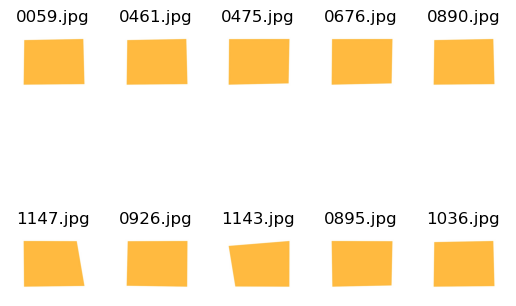

In [8]:
def display_images_from_folder(folder_path):
    # List all files in the given folder
    files = [file for file in os.listdir(folder_path) if file.lower().endswith(('jpg'))]
    
    # Display the first 10 images
    for i, file in enumerate(files[:10]):
        # Open the image file
        img_path = os.path.join(folder_path, file)
        img = Image.open(img_path)
        
        # Configure subplot
        plt.subplot(2, 5, i + 1)  # Display images in a 2x5 grid
        plt.imshow(img)
        plt.title(file)
        plt.axis('off')  # Turn off axis numbers and ticks
        
    plt.show()

# Path to the folder
cluster_number = input("Cluster number:")

cluster_folder = f"families/{cluster_number}"

display_images_from_folder(cluster_folder)
